In [3]:
import requests
from tqdm import tqdm

url      = "http://mrl.cs.vsb.cz/data/eyedataset/mrlEyes_2018_01.zip"
filename = "mrlEyes_2018_01.zip"

print(f"Downloading from:\n{url}\n")

response   = requests.get(url, stream=True)
total_size = int(response.headers.get("content-length", 0))
block_size = 1024  # 1 KB

with open(filename, "wb") as f:
    for data in tqdm(response.iter_content(block_size),
                     total=total_size // block_size,
                     unit="KB", desc="Downloading"):
        f.write(data)

print(f"\n✅ Download complete → {filename}")

http://mrl.cs.vsb.cz/data/eyedataset/mrlEyes_2018_01.zip



Downloading: 333855KB [01:58, 2817.57KB/s]                                                                                                                   


✅ Download complete → mrlEyes_2018_01.zip


In [4]:
import zipfile
import os

zip_path    = "mrlEyes_2018_01.zip"
extract_dir = "MRL_Eye_Dataset"

print(f"Extracting {zip_path} ...")

with zipfile.ZipFile(zip_path, "r") as z:
    members = z.namelist()
    for member in tqdm(members, desc="Extracting"):
        z.extract(member, extract_dir)

print(f"\n✅ Extracted to → {extract_dir}/")

# Auto-detect the inner folder name (handles any zip structure)
inner = [
    d for d in os.listdir(extract_dir)
    if os.path.isdir(os.path.join(extract_dir, d))
]
print(f"   Contents: {inner}")

SOURCE_FOLDER = os.path.join(extract_dir, inner[0])
print(f"\n📁 Source folder set to: {SOURCE_FOLDER}")


Extracting mrlEyes_2018_01.zip ...


Extracting: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 84938/84938 [03:49<00:00, 369.36it/s]


✅ Extracted to → MRL_Eye_Dataset/
   Contents: ['mrlEyes_2018_01']

📁 Source folder set to: MRL_Eye_Dataset\mrlEyes_2018_01


In [5]:
# ─────────────────────────────────────────────
#  CELL 3 — Organize into dataset/train & test
# ─────────────────────────────────────────────
import os
import shutil
import random
from tqdm import tqdm
from collections import defaultdict

# SOURCE_FOLDER is set automatically from Cell 2.
# If you skip Cell 2, set it manually:
# SOURCE_FOLDER = "MRL_Eye_Dataset/mrlEyes_2018_01"

TRAIN_RATIO = 0.8
random.seed(42)

# MRL filename format:
# s<subj> _ <imgid> _ <light> _ <glasses> _ <eye_state> _ <refl> _ ...
#   [0]      [1]       [2]       [3]          [4] ← label index
#   eye_state:  0 = closed,  1 = open

# Create output dirs
for split in ["train", "test"]:
    for cls in ["open", "closed"]:
        os.makedirs(f"dataset/{split}/{cls}", exist_ok=True)

# List subject folders
subjects = [
    s for s in os.listdir(SOURCE_FOLDER)
    if os.path.isdir(os.path.join(SOURCE_FOLDER, s)) and s.startswith("s")
]
print(f"Found {len(subjects)} subjects in {SOURCE_FOLDER}\n")

counts = defaultdict(int)
skipped = 0

for subject in tqdm(subjects, desc="Organizing"):
    subject_path = os.path.join(SOURCE_FOLDER, subject)
    images = [img for img in os.listdir(subject_path) if img.endswith(".png")]

    random.shuffle(images)
    split_idx    = int(len(images) * TRAIN_RATIO)
    train_images = images[:split_idx]
    test_images  = images[split_idx:]

    for split, img_list in [("train", train_images), ("test", test_images)]:
        for img in img_list:
            parts = img.split("_")

            if len(parts) < 5:          # malformed filename
                skipped += 1
                continue

            eye_state = parts[4]        # ✅ correct index

            if eye_state == "1":
                cls = "open"
            elif eye_state == "0":
                cls = "closed"
            else:
                skipped += 1
                continue

            src  = os.path.join(subject_path, img)
            dest = f"dataset/{split}/{cls}"
            shutil.copy(src, dest)
            counts[f"{split}/{cls}"] += 1

# ── Summary ──────────────────────────────────
print(f"\n✅ Dataset organized! ({skipped} files skipped)\n")
print(f"{'Split':<8} {'Class':<10} {'Images':>8}")
print("─" * 28)
for key in ["train/open", "train/closed", "test/open", "test/closed"]:
    split, cls = key.split("/")
    print(f"{split:<8} {cls:<10} {counts[key]:>8,}")

print("─" * 28)
print(f"{'TOTAL':<18} {sum(counts.values()):>8,}")
print(f"\n📁 Your dataset/ folder is ready for training!")

Found 37 subjects in MRL_Eye_Dataset\mrlEyes_2018_01



Organizing: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [03:42<00:00,  6.01s/it]


✅ Dataset organized! (0 files skipped)

Split    Class        Images
────────────────────────────
train    open         34,361
train    closed       33,542
test     open          8,591
test     closed        8,404
────────────────────────────
TOTAL                84,898

📁 Your dataset/ folder is ready for training!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Found 67903 images belonging to 2 classes.
Found 16995 images belonging to 2 classes.

✅ Data loaded!
   Class indices : {'closed': 0, 'open': 1}
   Train batches : 2122
   Test  batches : 532


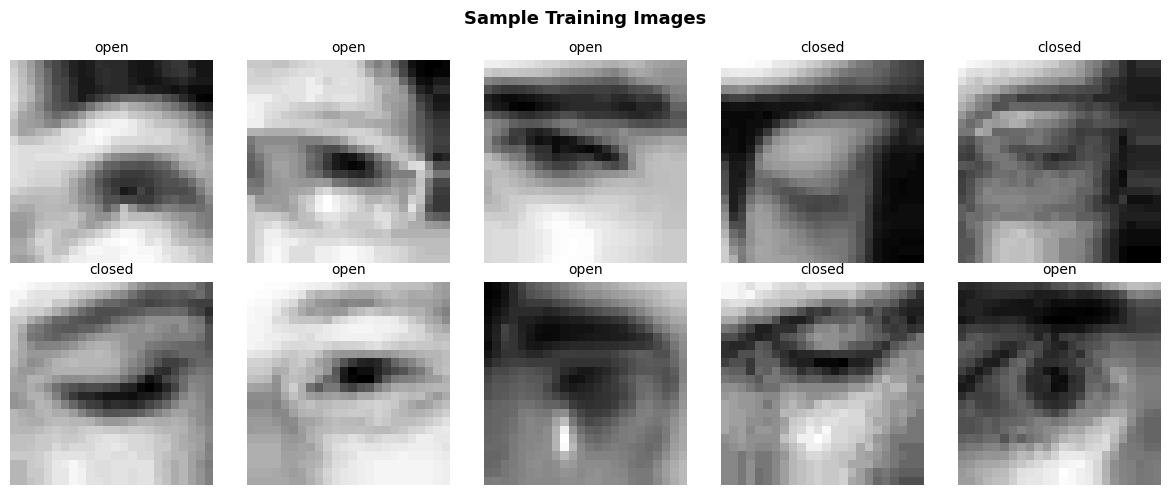

In [3]:
IMG_SIZE   = (24, 24)
BATCH_SIZE = 32

# Training: augmentation ON
train_datagen = ImageDataGenerator(
    rescale = 1.0 / 255.0,
    rotation_range = 10,
    zoom_range = 0.1,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    brightness_range = [0.8, 1.2],
)

# Test: only rescale
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_gen = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=42,
)

test_gen = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

print(f"\n✅ Data loaded!")
print(f"   Class indices : {train_gen.class_indices}")  # {'closed': 0, 'open': 1}
print(f"   Train batches : {len(train_gen)}")
print(f"   Test  batches : {len(test_gen)}")

# Preview sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Training Images", fontsize=13, fontweight="bold")
images, labels = next(train_gen)
label_names = {v: k for k, v in train_gen.class_indices.items()}
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(label_names[int(round(labels[i]))], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dropout,
    Flatten, Dense, BatchNormalization
)
from tensorflow.keras.optimizers import Adam

In [14]:

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dropout,
    Flatten, Dense, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)


IMG_SIZE   = (24, 24)
BATCH_SIZE = 32
EPOCHS     = 20

# ── STEP 1: Load Data ─────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_gen = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=42,
)
test_gen = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)
print(f"✅ Data loaded — class indices: {train_gen.class_indices}")

# ── STEP 2: Build Model ───────────────────────
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(24, 24, 1)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Classifier
    Flatten(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.summary()

# ── STEP 3: Train ─────────────────────────────
callbacks = [
    ModelCheckpoint(
        "drowsiness_model.h5",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    callbacks=callbacks,
)

print("\n✅ Training complete → drowsiness_model.h5 saved!")

Found 67903 images belonging to 2 classes.
Found 16995 images belonging to 2 classes.
✅ Data loaded — class indices: {'closed': 0, 'open': 1}


C:\Users\KIIT\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 24, 24, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 24, 24, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 12, 12, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 12, 12, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 6, 6, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 6, 6, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 390,017 (1.49 MB)

...

2122/2122 ━━━━━━━━━━━━━━━━━━━━ 277s 130ms/step - accuracy: 0.9482 - loss: 0.1372 - val_accuracy: 0.9691 - val_loss: 0.0840
Epoch 4/20
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9510 - loss: 0.1298
Epoch 4: val_loss did not improve from 0.08396
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 289s 136ms/step - accuracy: 0.9537 - loss: 0.1246 - val_accuracy: 0.9562 - val_loss: 0.1270
Epoch 5/20
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9529 - loss: 0.1250
Epoch 5: val_loss improved from 0.08396 to 0.06976, saving model to drowsiness_model.h5


2122/2122 ━━━━━━━━━━━━━━━━━━━━ 313s 132ms/step - accuracy: 0.9550 - loss: 0.1207 - val_accuracy: 0.9752 - val_loss: 0.0698
Epoch 6/20
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9600 - loss: 0.1100
Epoch 6: val_loss improved from 0.06976 to 0.06846, saving model to drowsiness_model.h5


2122/2122 ━━━━━━━━━━━━━━━━━━━━ 369s 174ms/step - accuracy: 0.9588 - loss: 0.1112 - val_accuracy: 0.9751 - val_loss: 0.0685
Epoch 7/20
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9614 - loss: 0.1040
Epoch 7: val_loss improved from 0.06846 to 0.06178, saving model to drowsiness_model.h5


2122/2122 ━━━━━━━━━━━━━━━━━━━━ 396s 187ms/step - accuracy: 0.9608 - loss: 0.1067 - val_accuracy: 0.9772 - val_loss: 0.0618
Epoch 8/20
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9640 - loss: 0.0990
Epoch 8: val_loss did not improve from 0.06178
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 212s 100ms/step - accuracy: 0.9636 - loss: 0.0986 - val_accuracy: 0.9717 - val_loss: 0.0902
Epoch 9/20
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9642 - loss: 0.0987
Epoch 9: val_loss improved from 0.06178 to 0.04889, saving model to drowsiness_model.h5


2122/2122 ━━━━━━━━━━━━━━━━━━━━ 201s 95ms/step - accuracy: 0.9647 - loss: 0.0977 - val_accuracy: 0.9815 - val_loss: 0.0489
Epoch 10/20
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9668 - loss: 0.0903
Epoch 10: val_loss did not improve from 0.04889
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 243s 114ms/step - accuracy: 0.9666 - loss: 0.0921 - val_accuracy: 0.9805 - val_loss: 0.0550
Epoch 11/20
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9666 - loss: 0.0911
Epoch 11: val_loss did not improve from 0.04889
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 175s 82ms/step - accuracy: 0.9669 - loss: 0.0916 - val_accuracy: 0.9788 - val_loss: 0.0569
Epoch 12/20
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9685 - loss: 0.0884
Epoch 12: val_loss did not improve from 0.04889
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 158s 75ms/step - accuracy: 0.9690 - loss: 0.0864 - val_accuracy: 0.9811 - val_loss: 0.0523
Epoch 13/20
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9687 - loss: 0.0854
Epoch 

In [16]:
!pip install seaborn


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

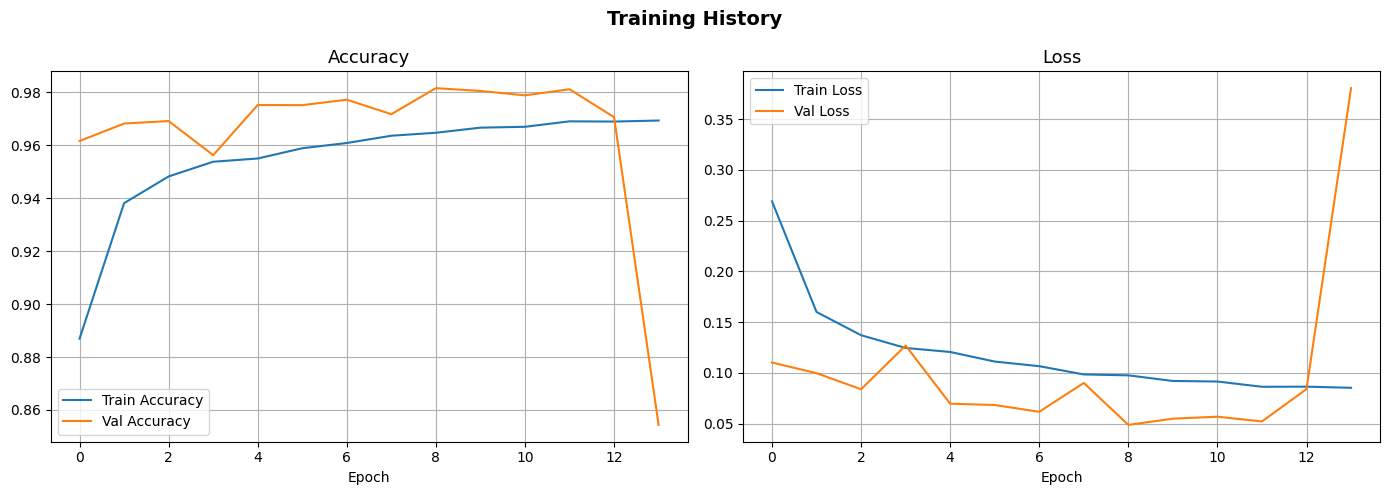

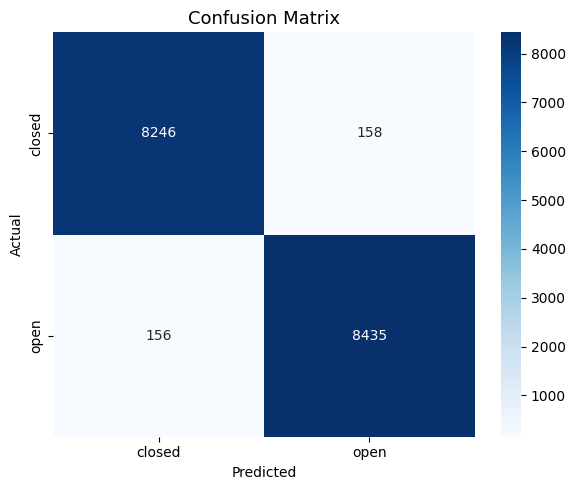


Classification Report:
              precision    recall  f1-score   support

      closed       0.98      0.98      0.98      8404
        open       0.98      0.98      0.98      8591

    accuracy                           0.98     16995
   macro avg       0.98      0.98      0.98     16995
weighted avg       0.98      0.98      0.98     16995

Test Accuracy : 98.15%
Test Loss     : 0.0489


In [19]:

# ── Accuracy & Loss curves ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Confusion matrix ──────────────────────────
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()
y_true      = test_gen.classes

class_names = list(test_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix", fontsize=13)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# ── Classification report ─────────────────────
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

loss, acc = model.evaluate(test_gen, verbose=0)
print(f"Test Accuracy : {acc * 100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

In [21]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from pygame import mixer
import time 

pygame 2.3.0 (SDL 2.24.2, Python 3.10.10)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [43]:
# ─────────────────────────────────────────────
# REAL-TIME DRIVER DROWSINESS DETECTION
# ─────────────────────────────────────────────

# ── CONFIG ────────────────────────────────────
MODEL_PATH       = "drowsiness_model.h5"
ALARM_SOUND      = "alarm.wav"
IMG_SIZE         = (24, 24)
CLOSED_THRESHOLD = 15   # frames before alarm (15 ≈ 0.5s at 30fps)
WINDOW_NAME      = "Driver Drowsiness Detection"
# ─────────────────────────────────────────────

# ── Load Model & Cascades ─────────────────────
model        = load_model(MODEL_PATH)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

# ── Alarm Setup ──────────────────────────────
mixer.init()
alarm_on = False

def trigger_alarm():
    global alarm_on
    if not alarm_on:
        mixer.music.load(ALARM_SOUND)
        mixer.music.play(-1)
        alarm_on = True

def stop_alarm():
    global alarm_on
    if alarm_on:
        mixer.music.stop()
        alarm_on = False

# ── Eye Prediction ───────────────────────────
def predict_eye(eye_roi):
    eye = cv2.resize(eye_roi, IMG_SIZE)
    eye = eye.astype("float32") / 255.0
    eye = np.expand_dims(eye, axis=(0, -1))
    prob = model.predict(eye, verbose=0)[0][0]
    return ("open" if prob >= 0.5 else "closed"), float(prob)

# ── Draw Progress Bar ────────────────────────
def draw_progress_bar(frame, closed_frames, threshold):
    H, W = frame.shape[:2]
    pct   = min(closed_frames / threshold, 1.0)
    bx, by, bw, bh = 20, H - 40, W - 40, 18

    # Background
    cv2.rectangle(frame, (bx, by), (bx + bw, by + bh), (40, 40, 40), -1)
    cv2.rectangle(frame, (bx, by), (bx + bw, by + bh), (100, 100, 100), 1)

    # Fill — green → yellow → red based on progress
    fill_w = int(bw * pct)
    if pct < 0.5:
        color = (0, 220, 0)
    elif pct < 0.85:
        color = (0, 200, 255)
    else:
        color = (0, 0, 255)
    if fill_w > 0:
        cv2.rectangle(frame, (bx, by), (bx + fill_w, by + bh), color, -1)

    label = f"Drowsiness: {int(pct * 100)}%  ({closed_frames}/{threshold} frames)"
    cv2.putText(frame, label, (bx, by - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.48, (210, 210, 210), 1)

# ── Draw HUD ─────────────────────────────────
def draw_hud(frame, fps, drowsy, closed_frames, threshold):
    H, W = frame.shape[:2]

    # Status banner
    if drowsy:
        # Flashing red border
        if int(time.time() * 2) % 2 == 0:
            cv2.rectangle(frame, (0, 0), (W - 1, H - 1), (0, 0, 255), 6)
        cv2.putText(frame, "DROWSINESS ALERT!", (W // 2 - 180, 55),
                    cv2.FONT_HERSHEY_DUPLEX, 1.3, (0, 0, 255), 3)
    else:
        status = "EYES OPEN" if closed_frames == 0 else "EYES CLOSING..."
        color  = (0, 220, 0) if closed_frames == 0 else (0, 200, 255)
        cv2.putText(frame, f"STATUS: {status}", (20, 40),
                    cv2.FONT_HERSHEY_DUPLEX, 0.9, color, 2)

    # FPS
    cv2.putText(frame, f"FPS: {fps:.1f}", (W - 110, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (180, 180, 180), 1)

    # Progress bar
    draw_progress_bar(frame, closed_frames, threshold)

# ── Main Loop ────────────────────────────────
cap = cv2.VideoCapture(0)
cv2.namedWindow(WINDOW_NAME, cv2.WINDOW_NORMAL)

closed_frames = 0
fps_time      = time.time()
no_face_count = 0          # track how long face is missing

print("🎥 Starting... Press Q or ESC to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Camera read failed.")
        break

    # ✅ Exit when window X button is clicked
    if cv2.getWindowProperty(WINDOW_NAME, cv2.WND_PROP_VISIBLE) < 1:
        break

    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5, minSize=(80, 80))

    eyes_this_frame  = []
    detected_any_eye = False

    for (x, y, w, h) in faces:
        # Face box
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 200, 0), 2)
        cv2.putText(frame, "Face", (x, y - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 200, 0), 1)

        roi_gray = gray[y:y + h, x:x + w]
        eyes     = eye_cascade.detectMultiScale(roi_gray, 1.1, 10, minSize=(20, 20))

        for (ex, ey, ew, eh) in eyes[:2]:
            detected_any_eye = True
            eye_roi          = roi_gray[ey:ey + eh, ex:ex + ew]
            label, prob      = predict_eye(eye_roi)
            eyes_this_frame.append(label)

            color = (0, 255, 0) if label == "open" else (0, 0, 255)
            cv2.rectangle(frame, (x + ex, y + ey), (x + ex + ew, y + ey + eh), color, 2)
            cv2.putText(frame, f"{label} {prob:.2f}",
                        (x + ex, y + ey - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.48, color, 1)

    # ── Drowsiness Logic ─────────────────────
    if detected_any_eye:
        no_face_count = 0
        if any(e == "closed" for e in eyes_this_frame):
            closed_frames += 1
        else:
            closed_frames = max(0, closed_frames - 1)   # gradual decay
            if closed_frames == 0:
                stop_alarm()
    else:
        no_face_count += 1
        if no_face_count > 30:       # reset only after 30 frames of no face
            closed_frames = 0
            stop_alarm()

        # Show no-face warning
        cv2.putText(frame, "No face detected", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (100, 100, 255), 2)

    drowsy = closed_frames >= CLOSED_THRESHOLD
    if drowsy:
        trigger_alarm()

    # ── FPS ──────────────────────────────────
    fps      = 1.0 / (time.time() - fps_time + 1e-6)
    fps_time = time.time()

    # ── Draw HUD ─────────────────────────────
    draw_hud(frame, fps, drowsy, closed_frames, CLOSED_THRESHOLD)

    cv2.imshow(WINDOW_NAME, frame)

    key = cv2.waitKey(1) & 0xFF
    if key == ord("q") or key == 27:   # Q or ESC
        break

# ── Cleanup ──────────────────────────────────
cap.release()
cv2.destroyAllWindows()
stop_alarm()
mixer.quit()
print("👋 Detection Stopped.")

🎥 Starting... Press Q or ESC to quit.
👋 Detection Stopped.
